# 2.6 概率

# 2.6.1 基本概率论

In [1]:
import torch
from torch.distributions import multinomial
from d2l import torch as d2l

In [ ]:
fair_probs = torch.ones(6)/6
# 给定六个元素，每个元素被选中的概率相等
multinomial.Multinomial(1, fair_probs).sample()
# 从这六个元素中进行一次抽样

tensor([0., 0., 0., 1., 0., 0.])

In [ ]:
multinomial.Multinomial(10, fair_probs).sample()
# 从这六个元素中进行十次抽样

tensor([3., 2., 0., 4., 1., 0.])

In [ ]:
counts = multinomial.Multinomial(1000, fair_probs).sample()
# 从这六个元素中进行一千次抽样,每个元素被抽样的次数除以总次数约等于1/6
counts / 1000

tensor([0.1840, 0.1560, 0.1910, 0.1680, 0.1500, 0.1510])

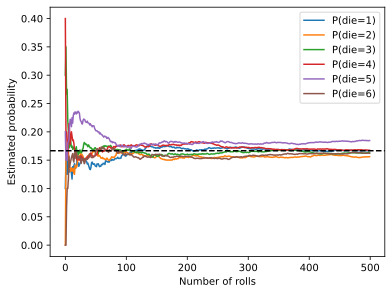

In [12]:
counts = multinomial.Multinomial(10, fair_probs).sample((500,))
cum_counts = counts.cumsum(dim=0)
estimates = cum_counts / cum_counts.sum(dim=1, keepdim=True)

d2l.set_figsize((6,4.5))
for i in range(6):
    d2l.plt.plot(estimates[:, i].numpy(), label=("P(die=" + str(i+1) + ")"))
d2l.plt.axhline(y=1/6, color='black', linestyle='dashed')
d2l.plt.gca().set_xlabel('Number of rolls')
d2l.plt.gca().set_ylabel('Estimated probability')
d2l.plt.legend();